In [1]:
!pip install yfinance scipy scikit-learn tensorflow

In [3]:
!mkdir src
!mkdir outputs

mkdir: cannot create directory ‘src’: File exists
mkdir: cannot create directory ‘outputs’: File exists


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.signal import stft
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [5]:
def load_data(ticker="AAPL", period="1y"):
    data = yf.download(ticker, period=period)
    return data['Close'].values

data = load_data()

/tmp/ipykernel_2159/1764720296.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period)
[*********************100%***********************]  1 of 1 completed


In [6]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1,1)).flatten()

In [7]:
def generate_spectrogram(signal):
    f, t, Zxx = stft(signal, nperseg=32)
    return np.abs(Zxx)

spectrogram = generate_spectrogram(data_scaled)

In [8]:
window_size = 32
X, y = [], []

for i in range(len(data_scaled) - window_size):
    segment = data_scaled[i:i+window_size]
    spec = generate_spectrogram(segment)
    X.append(spec)
    y.append(data_scaled[i+window_size])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

In [9]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [12]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=X.shape[1:]),
    MaxPooling2D((2,1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

In [13]:
model.fit(X_train, y_train, epochs=10, batch_size=16)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3586
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1745 
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0395 
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0302 
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0190 
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0168 
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0135 
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0117 
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102 
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0090 


In [14]:
predictions = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [15]:
future_steps = 10
future_predictions = []

last_window = data_scaled[-window_size:]

for _ in range(future_steps):
    spec = generate_spectrogram(last_window)
    spec = spec.reshape(1, spec.shape[0], spec.shape[1], 1)

    next_pred = model.predict(spec)[0][0]
    future_predictions.append(next_pred)

    last_window = np.append(last_window[1:], next_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [16]:
predictions_rescaled = scaler.inverse_transform(predictions)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1,1))
future_rescaled = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))

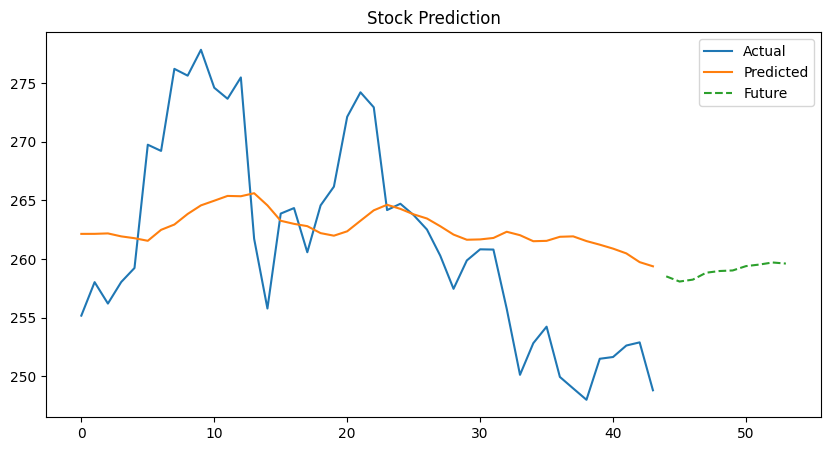

In [17]:
plt.figure(figsize=(10,5))

plt.plot(y_test_rescaled, label="Actual")
plt.plot(predictions_rescaled, label="Predicted")

plt.plot(range(len(y_test_rescaled), len(y_test_rescaled)+future_steps),
         future_rescaled, label="Future", linestyle='dashed')

plt.legend()
plt.title("Stock Prediction")
plt.savefig("outputs/prediction.png")
plt.show()

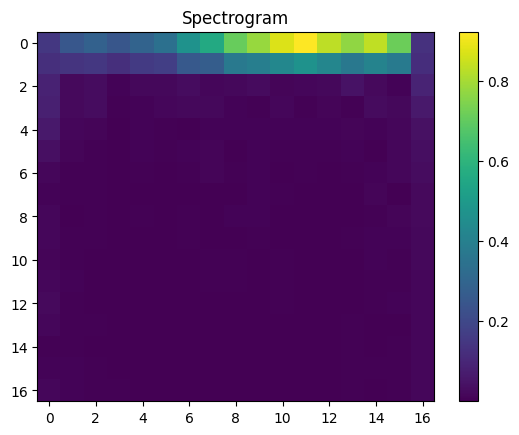

In [18]:
plt.imshow(spectrogram, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title("Spectrogram")
plt.savefig("outputs/spectrogram.png")
plt.show()

In [19]:
!ls outputs

prediction.png	spectrogram.png


In [20]:
from google.colab import files

files.download("outputs/prediction.png")
files.download("outputs/spectrogram.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>